In [1]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [25]:
import tensorflow as tf

In [26]:
!pip install tensorflow

  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl (332.0 MB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 594.1 kB/s eta 0:00:02
   ------------- -------------------------- 0.5/1.5 MB 594.1 kB/s eta 0:00:02
   -------------------- ------------------- 0.8/1.5 MB 565.5 kB/s eta 0:00:02
   -------------------- ------------------- 0.8/1.5 MB 565.5 kB/s eta 0:00:02
   --------------------------- ------------ 1.0/1.5 MB 577.2 kB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.5 MB 577.2 kB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 692.0 kB/s  0:00:02

   --------------------------------

In [2]:
from datasets import load_dataset

# Load the dataset from Hugging Face
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")

# Convert to pandas DataFrame
df = dataset["train"].to_pandas()

# Preview
print(df.head())

                                             subject  \
0                    Wesentlicher Sicherheitsvorfall   
1                                 Account Disruption   
2  Query About Smart Home System Integration Feat...   
3                  Inquiry Regarding Invoice Details   
4  Question About Marketing Agency Software Compa...   

                                                body  \
0  Sehr geehrtes Support-Team,\n\nich möchte eine...   
1  Dear Customer Support Team,\n\nI am writing to...   
2  Dear Customer Support Team,\n\nI hope this mes...   
3  Dear Customer Support Team,\n\nI hope this mes...   
4  Dear Support Team,\n\nI hope this message reac...   

                                              answer      type  \
0  Vielen Dank für die Meldung des kritischen Sic...  Incident   
1  Thank you for reaching out, <name>. We are awa...  Incident   
2  Thank you for your inquiry. Our products suppo...   Request   
3  We appreciate you reaching out with your billi...   Request

In [3]:
df = df[["body", "queue"]]   # Keep only the needed columns
df.dropna(subset=["body", "queue"], inplace=True)

In [27]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df["body"])

sequences = tokenizer.texts_to_sequences(df["body"])
X_pad = pad_sequences(sequences, maxlen=200, padding='post', truncating='post')

In [5]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(df["queue"])

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

In [11]:
import zipfile
import requests

url = "http://nlp.stanford.edu/data/glove.6B.zip"
response = requests.get(url)

with open("glove.6B.zip", "wb") as f:
    f.write(response.content)

with zipfile.ZipFile("glove.6B.zip", "r") as zip_ref:
    zip_ref.extractall("glove")

In [12]:
import numpy as np

In [13]:
embedding_index = {}
with open("glove/glove.6B.100d.txt", encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coeffs

embedding_dim = 100
word_index = tokenizer.word_index
embedding_matrix = np.zeros((10000, embedding_dim))

for word, i in word_index.items():
    if i < 10000:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

num_classes = len(encoder.classes_)  # Number of unique queues

model = Sequential([
    Embedding(input_dim=10000,
              output_dim=100,
              input_length=200,
              weights=[embedding_matrix],
              trainable=True),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

C:\Users\Kiran Kumar\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [15]:
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 227s 355ms/step - accuracy: 0.2391 - loss: 2.4288 - val_accuracy: 0.2987 - val_loss: 2.1883
Epoch 2/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 218s 353ms/step - accuracy: 0.3086 - loss: 2.1330 - val_accuracy: 0.3363 - val_loss: 2.0233
Epoch 3/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 224s 362ms/step - accuracy: 0.3494 - loss: 1.9451 - val_accuracy: 0.3629 - val_loss: 1.8726
Epoch 4/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 221s 357ms/step - accuracy: 0.4000 - loss: 1.7517 - val_accuracy: 0.3948 - val_loss: 1.7598
Epoch 5/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 222s 359ms/step - accuracy: 0.4510 - loss: 1.5744 - val_accuracy: 0.4384 - val_loss: 1.6582
Epoch 6/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 223s 361ms/step - accuracy: 0.5120 - loss: 1.4075 - val_accuracy: 0.4670 - val_loss: 1.6067
Epoch 7/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 178s 288ms/step - accuracy: 0.5693 - loss: 1.2467 - val_accuracy: 0.4933 - val_loss: 1.5387
Epoch 8/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 171s 276ms/step - accuracy: 0.6185 -

In [23]:
model.save("ticket_classifier.keras")

In [16]:
model.save("ticket_classifier.h5")

import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

In [17]:
!pip install google-generativeai

In [18]:
pip install --upgrade google-generativeai

Note: you may need to restart the kernel to use updated packages.


In [19]:
!pip install google-generativeai

In [20]:
import google.generativeai as genai

# Configure with your API key
genai.configure(api_key="YOUR_API_KEY_HERE")

# Load the model
gemini_model = genai.GenerativeModel("models/gemini-2.5-flash")

# Test
response = gemini_model.generate_content("Hello Gemini")
print(response.text)

C:\Users\Kiran Kumar\AppData\Local\Temp\ipykernel_10884\823608829.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Hello! How can I help you today?


In [24]:
import pickle
import numpy as np
from tensorflow.keras.models import load_model

# 1. Load the trained model
model = load_model("ticket_classifier.keras")

# 2. Load the encoder (needed for the classification report)
with open("label_encoder.pkl", "rb") as f:
    encoder = pickle.load(f)

print("Model and Data loaded")

Model and Data loaded


C:\Users\Kiran Kumar\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 24 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


387/387 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step
Classification Report:
                                        precision    recall  f1-score   support

           Arts & Entertainment/Movies       0.69      0.76      0.73        54
            Arts & Entertainment/Music       0.78      0.82      0.80        77
          Autos & Vehicles/Maintenance       0.62      0.48      0.55        62
                Autos & Vehicles/Sales       0.49      0.68      0.57        66
            Beauty & Fitness/Cosmetics       0.78      0.93      0.85        55
     Beauty & Fitness/Fitness Training       0.84      0.80      0.82        60
                  Billing and Payments       0.84      0.70      0.76       972
            Books & Literature/Fiction       0.84      0.88      0.86        52
        Books & Literature/Non-Fiction       0.81      0.62      0.70        63
   Business & Industrial/Manufacturing       0.71      0.62      0.66        73
                      Customer Service       0.40    

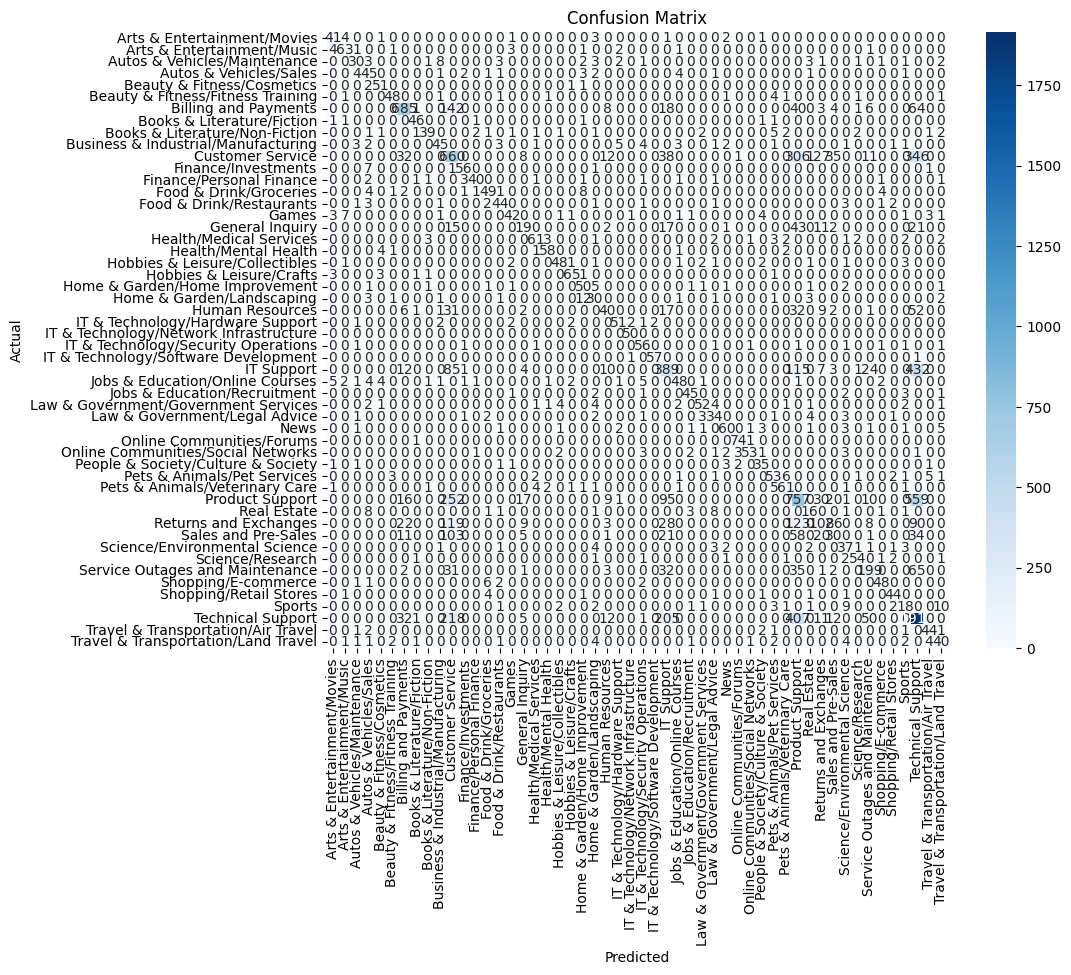

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Make predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Generate Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# 3. Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()